# Surface-code threshold sweep on EC2

Run this notebook from the same directory as `surface_code_hpc.py`, `sweep_config.py`, and `aggregate.py`.

The main timing values are:

- `wall_clock_total_sec`: real elapsed time from launching the sweep to finishing every task.
- `sum_replica_elapsed_sec`: sum of each replica's internal compute time. This is useful when running with multiple workers because it can be much larger than wall-clock time.
- `aggregate_elapsed_sec`: time spent aggregating JSON results into the summary table and plot.

## 1. Install dependencies

Run this cell once on a fresh EC2 instance or fresh virtual environment.

In [1]:
%pip install --upgrade pip
%pip install numpy matplotlib
%pip install --only-binary=:all: stim pymatching

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 2. Configure the EC2 run

By default this uses the sweep already defined in `sweep_config.py`:

- distances: 3, 5, 7, 9
- 8 physical error rates from 0.001 to 0.02
- 4 replicas per point
- 100,000 shots per replica

`MAX_WORKERS` defaults to at most 16 concurrent tasks, matching the original Slurm array limit. Increase it if your EC2 instance has enough vCPU and memory.

In [2]:
import concurrent.futures as cf
import csv
import datetime as dt
import glob
import json
import os
import platform
import subprocess
import sys
import time
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import sweep_config
from aggregate import wilson_ci

BASE_DIR = Path.cwd()
RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

RUN_ID = dt.datetime.now().strftime("ec2_%Y%m%d_%H%M%S")
MAX_WORKERS = min(16, os.cpu_count() or 1, len(sweep_config.grid()))
PYTHON = sys.executable

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

print(f"run_id: {RUN_ID}")
print(f"base_dir: {BASE_DIR}")
print(f"python: {PYTHON}")
print(f"host: {platform.node()}")
print(f"max_workers: {MAX_WORKERS}")
print(f"total_tasks: {len(sweep_config.grid())}")
print(f"shots_per_replica: {sweep_config.SHOTS_PER_REPLICA:,}")

run_id: ec2_20260608_055729
base_dir: /home/ec2-user/SageMaker/Project/Surface code/surface_code
python: /home/ec2-user/anaconda3/envs/Braket/bin/python
host: ip-172-23-213-237.ec2.internal
max_workers: 2
total_tasks: 128
shots_per_replica: 100,000


## 3. Build the task list

In [3]:
tasks = []
for idx in range(len(sweep_config.grid())):
    distance, p, replica, seed = sweep_config.task_params(idx)
    output = RESULTS_DIR / f"threshold_{RUN_ID}_{idx}.json"
    tasks.append({
        "idx": idx,
        "distance": distance,
        "p": p,
        "replica": replica,
        "seed": seed,
        "shots": sweep_config.SHOTS_PER_REPLICA,
        "output": str(output),
    })

tasks[:5], tasks[-1]

([{'idx': 0,
   'distance': 3,
   'p': 0.001,
   'replica': 0,
   'seed': 54321,
   'shots': 100000,
   'output': '/home/ec2-user/SageMaker/Project/Surface code/surface_code/results/threshold_ec2_20260608_055729_0.json'},
  {'idx': 1,
   'distance': 3,
   'p': 0.001,
   'replica': 1,
   'seed': 1054324,
   'shots': 100000,
   'output': '/home/ec2-user/SageMaker/Project/Surface code/surface_code/results/threshold_ec2_20260608_055729_1.json'},
  {'idx': 2,
   'distance': 3,
   'p': 0.001,
   'replica': 2,
   'seed': 2054327,
   'shots': 100000,
   'output': '/home/ec2-user/SageMaker/Project/Surface code/surface_code/results/threshold_ec2_20260608_055729_2.json'},
  {'idx': 3,
   'distance': 3,
   'p': 0.001,
   'replica': 3,
   'seed': 3054330,
   'shots': 100000,
   'output': '/home/ec2-user/SageMaker/Project/Surface code/surface_code/results/threshold_ec2_20260608_055729_3.json'},
  {'idx': 4,
   'distance': 3,
   'p': 0.0015341274046343915,
   'replica': 0,
   'seed': 4054333,
   'sho

## 4. Run the sweep and measure total time

This cell starts one subprocess per replica and runs up to `MAX_WORKERS` subprocesses at a time.

In [4]:
def run_task(task):
    cmd = [
        PYTHON,
        "surface_code_hpc.py",
        "--distance", str(task["distance"]),
        "--error-rate", f"{task['p']:.8f}",
        "--shots", str(task["shots"]),
        "--seed", str(task["seed"]),
        "--replica", str(task["replica"]),
        "--output", task["output"],
    ]
    t0 = time.perf_counter()
    completed = subprocess.run(
        cmd,
        cwd=BASE_DIR,
        text=True,
        capture_output=True,
        check=False,
    )
    wall_sec = time.perf_counter() - t0
    return {
        **task,
        "returncode": completed.returncode,
        "subprocess_wall_sec": wall_sec,
        "stdout": completed.stdout,
        "stderr": completed.stderr,
    }


sweep_start_iso = dt.datetime.now(dt.timezone.utc).isoformat()
sweep_t0 = time.perf_counter()
task_results = []

print(f"Starting {len(tasks)} tasks with {MAX_WORKERS} workers...")
with cf.ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(run_task, task): task for task in tasks}
    for done_count, future in enumerate(cf.as_completed(futures), start=1):
        result = future.result()
        task_results.append(result)
        if result["returncode"] != 0:
            print(f"FAILED task={result['idx']} d={result['distance']} p={result['p']:.8f}")
            print(result["stderr"][-2000:])
        elif done_count == 1 or done_count % max(1, len(tasks) // 20) == 0 or done_count == len(tasks):
            elapsed = time.perf_counter() - sweep_t0
            print(f"{done_count:>4}/{len(tasks)} done, wall elapsed={elapsed:.1f}s")

wall_clock_total_sec = time.perf_counter() - sweep_t0
sweep_end_iso = dt.datetime.now(dt.timezone.utc).isoformat()

failed = [r for r in task_results if r["returncode"] != 0]
if failed:
    raise RuntimeError(f"{len(failed)} task(s) failed. Inspect task_results for stderr.")

print(f"wall_clock_total_sec = {wall_clock_total_sec:.3f}")

Starting 128 tasks with 2 workers...
   1/128 done, wall elapsed=1.5s
   6/128 done, wall elapsed=3.5s
  12/128 done, wall elapsed=6.6s
  18/128 done, wall elapsed=9.7s
  24/128 done, wall elapsed=12.9s
  30/128 done, wall elapsed=16.5s
  36/128 done, wall elapsed=20.4s
  42/128 done, wall elapsed=24.3s
  48/128 done, wall elapsed=28.5s
  54/128 done, wall elapsed=35.8s
  60/128 done, wall elapsed=43.9s
  66/128 done, wall elapsed=52.9s
  72/128 done, wall elapsed=58.9s
  78/128 done, wall elapsed=66.1s
  84/128 done, wall elapsed=76.7s
  90/128 done, wall elapsed=94.4s
  96/128 done, wall elapsed=124.4s
 102/128 done, wall elapsed=134.5s
 108/128 done, wall elapsed=146.2s
 114/128 done, wall elapsed=167.5s
 120/128 done, wall elapsed=198.9s
 126/128 done, wall elapsed=265.2s
 128/128 done, wall elapsed=292.8s
wall_clock_total_sec = 292.812


## 5. Aggregate results and save timing summary

In [5]:
def aggregate_run(run_id):
    files = sorted(glob.glob(str(RESULTS_DIR / f"threshold_{run_id}_*.json")))
    if not files:
        raise FileNotFoundError(f"No result files found for {run_id}")

    acc = defaultdict(lambda: {"errors": 0, "shots": 0, "replicas": 0, "elapsed": 0.0})
    meta = {}
    records = []
    for path in files:
        with open(path) as f:
            record = json.load(f)
        record["_result_path"] = path
        record["_task_idx"] = int(Path(path).stem.rsplit("_", 1)[-1])
        records.append(record)
        p = record.get("physical_error_rate", record.get("error_rate"))
        key = (record["distance"], round(float(p), 8))
        acc[key]["errors"] += record["logical_errors"]
        acc[key]["shots"] += record["shots"]
        acc[key]["replicas"] += 1
        acc[key]["elapsed"] += record.get("elapsed_sec", 0.0)
        meta[key] = record

    rows = []
    for key in sorted(acc):
        distance, p = key
        a = acc[key]
        m = meta[key]
        rate, lo, hi = wilson_ci(a["errors"], a["shots"])
        rows.append({
            "distance": distance,
            "physical_error_rate": p,
            "active_qubits": m["active_qubits"],
            "detectors": m["detectors"],
            "matching_edges": m["matching_edges"],
            "logical_errors": a["errors"],
            "shots": a["shots"],
            "replicas": a["replicas"],
            "logical_error_rate": rate,
            "ci95_low": lo,
            "ci95_high": hi,
            "total_elapsed_sec": a["elapsed"],
        })
    return files, records, rows


aggregate_t0 = time.perf_counter()
result_files, records, rows = aggregate_run(RUN_ID)
aggregate_elapsed_sec = time.perf_counter() - aggregate_t0
sum_replica_elapsed_sec = sum(r.get("elapsed_sec", 0.0) for r in records)
sum_subprocess_wall_sec = sum(r["subprocess_wall_sec"] for r in task_results)

task_wall_by_idx = {r["idx"]: r["subprocess_wall_sec"] for r in task_results}
distance_acc = defaultdict(lambda: {
    "tasks": 0,
    "shots": 0,
    "logical_errors": 0,
    "sum_replica_elapsed_sec": 0.0,
    "sum_subprocess_wall_sec": 0.0,
    "replica_elapsed_values": [],
})
for record in records:
    distance = record["distance"]
    idx = record.get("_task_idx")
    elapsed = record.get("elapsed_sec", 0.0)
    distance_acc[distance]["tasks"] += 1
    distance_acc[distance]["shots"] += record.get("shots", 0)
    distance_acc[distance]["logical_errors"] += record.get("logical_errors", 0)
    distance_acc[distance]["sum_replica_elapsed_sec"] += elapsed
    distance_acc[distance]["replica_elapsed_values"].append(elapsed)
    if idx is not None and idx in task_wall_by_idx:
        distance_acc[distance]["sum_subprocess_wall_sec"] += task_wall_by_idx[idx]

timing_by_distance = []
for distance, values in sorted(distance_acc.items()):
    replica_elapsed = values["replica_elapsed_values"]
    timing_by_distance.append({
        "distance": distance,
        "tasks": values["tasks"],
        "shots": values["shots"],
        "logical_errors": values["logical_errors"],
        "sum_replica_elapsed_sec": values["sum_replica_elapsed_sec"],
        "mean_replica_elapsed_sec": float(np.mean(replica_elapsed)) if replica_elapsed else 0.0,
        "min_replica_elapsed_sec": float(np.min(replica_elapsed)) if replica_elapsed else 0.0,
        "max_replica_elapsed_sec": float(np.max(replica_elapsed)) if replica_elapsed else 0.0,
        "sum_subprocess_wall_sec": values["sum_subprocess_wall_sec"],
    })

csv_path = BASE_DIR / f"threshold_summary_{RUN_ID}.csv"
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(rows[0]))
    writer.writeheader()
    writer.writerows(rows)

distance_timing_path = BASE_DIR / f"distance_timing_{RUN_ID}.csv"
with open(distance_timing_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(timing_by_distance[0]))
    writer.writeheader()
    writer.writerows(timing_by_distance)

timing_summary = {
    "run_id": RUN_ID,
    "host": platform.node(),
    "python": PYTHON,
    "max_workers": MAX_WORKERS,
    "total_tasks": len(tasks),
    "shots_per_replica": sweep_config.SHOTS_PER_REPLICA,
    "sweep_start_utc": sweep_start_iso,
    "sweep_end_utc": sweep_end_iso,
    "wall_clock_total_sec": wall_clock_total_sec,
    "sum_replica_elapsed_sec": sum_replica_elapsed_sec,
    "sum_subprocess_wall_sec": sum_subprocess_wall_sec,
    "aggregate_elapsed_sec": aggregate_elapsed_sec,
    "csv_path": str(csv_path),
    "distance_timing_path": str(distance_timing_path),
    "timing_by_distance": timing_by_distance,
    "result_file_count": len(result_files),
}

summary_path = RESULTS_DIR / f"run_summary_{RUN_ID}.json"
with open(summary_path, "w") as f:
    json.dump(timing_summary, f, indent=2)

print(json.dumps(timing_summary, indent=2))

{
  "run_id": "ec2_20260608_055729",
  "host": "ip-172-23-213-237.ec2.internal",
  "python": "/home/ec2-user/anaconda3/envs/Braket/bin/python",
  "max_workers": 2,
  "total_tasks": 128,
  "shots_per_replica": 100000,
  "sweep_start_utc": "2026-06-08T05:57:29.730641+00:00",
  "sweep_end_utc": "2026-06-08T06:02:22.542629+00:00",
  "wall_clock_total_sec": 292.8119044289924,
  "sum_replica_elapsed_sec": 452.5904676914215,
  "sum_subprocess_wall_sec": 585.0838358033216,
  "aggregate_elapsed_sec": 0.09727287909481674,
  "csv_path": "/home/ec2-user/SageMaker/Project/Surface code/surface_code/threshold_summary_ec2_20260608_055729.csv",
  "distance_timing_path": "/home/ec2-user/SageMaker/Project/Surface code/surface_code/distance_timing_ec2_20260608_055729.csv",
  "timing_by_distance": [
    {
      "distance": 3,
      "tasks": 32,
      "shots": 3200000,
      "logical_errors": 139119,
      "sum_replica_elapsed_sec": 4.445345640182495,
      "mean_replica_elapsed_sec": 0.13891705125570297,
 

## 6. Plot threshold curves

Saved plot: /home/ec2-user/SageMaker/Project/Surface code/surface_code/threshold_curve_ec2_20260608_055729.png


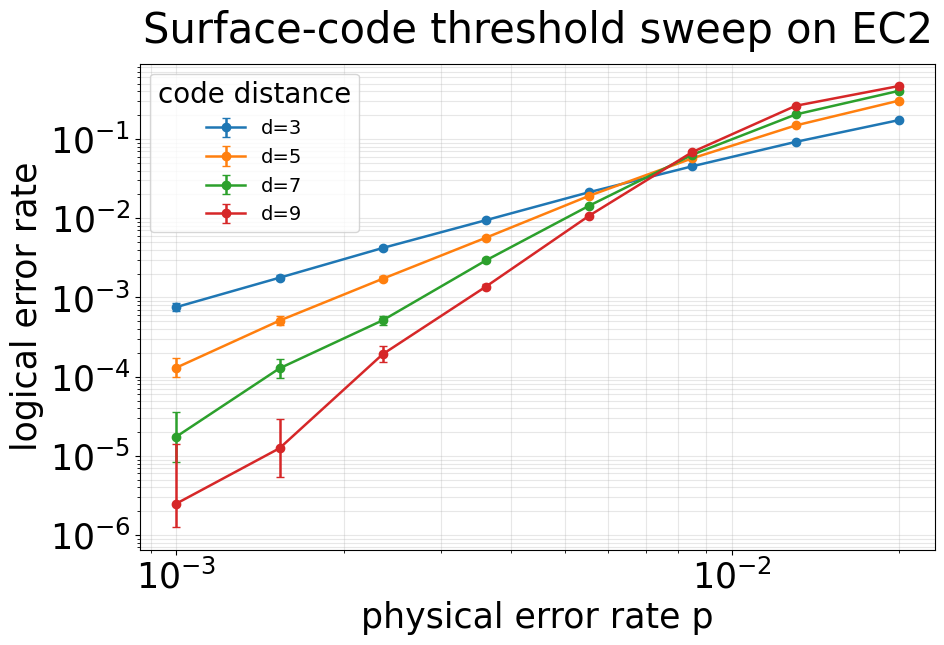

In [6]:
plot_path = BASE_DIR / f"threshold_curve_{RUN_ID}.png"

plt.rcParams.update({'font.size': 25})

fig, ax = plt.subplots(figsize=(10.0, 7.0))

for distance in sorted({row["distance"] for row in rows}):
    pts = sorted(
        [row for row in rows if row["distance"] == distance],
        key=lambda row: row["physical_error_rate"],
    )
    ps = np.array([row["physical_error_rate"] for row in pts])
    rates = np.array([row["logical_error_rate"] for row in pts])
    shots = np.array([row["shots"] for row in pts])
    plot_rates = np.maximum(rates, 0.5 / shots)
    lows = np.array([row["ci95_low"] for row in pts])
    highs = np.array([row["ci95_high"] for row in pts])
    yerr = np.array([
        np.maximum(0.0, plot_rates - np.maximum(lows, 0.5 / shots)),
        np.maximum(0.0, highs - plot_rates),
    ])
    ax.errorbar(ps, plot_rates, yerr=yerr, marker="o", capsize=3, linewidth=1.8, label=f"d={distance}")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("physical error rate p", fontsize=25)
ax.set_ylabel("logical error rate", fontsize=25)
ax.set_title("Surface-code threshold sweep on EC2", fontsize=30, pad=15)

ax.tick_params(axis='both', which='major', labelsize=25)

ax.grid(True, which="both", alpha=0.3)

ax.legend(title="code distance", fontsize=14, title_fontsize=20)

fig.tight_layout()
fig.savefig(plot_path, dpi=150) 

print(f"Saved plot: {plot_path}")
plt.show()

Saved plot: /home/ec2-user/SageMaker/Project/Surface code/surface_code/threshold_curve_ec2_20260608_055729.png


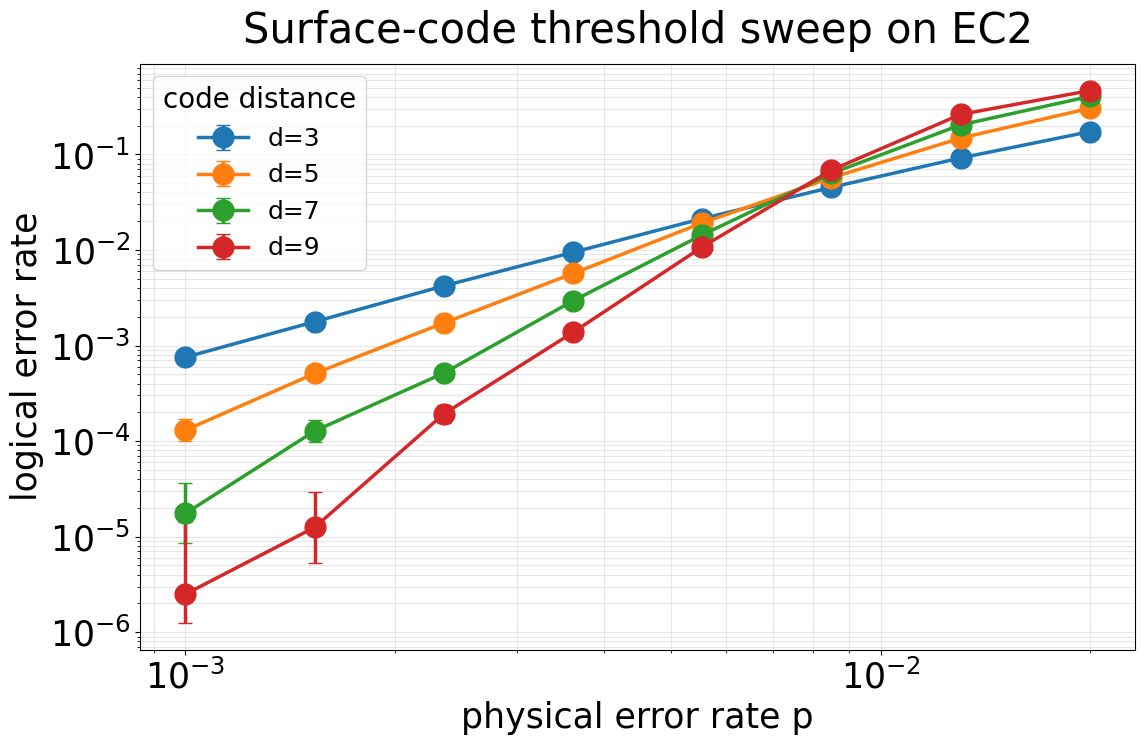

In [7]:
plot_path = BASE_DIR / f"threshold_curve_{RUN_ID}.png"

plt.rcParams.update({'font.size': 25})

# 建議將畫布再放大一點點，以容納 25 的超大字體，避免互相擠壓
fig, ax = plt.subplots(figsize=(12.0, 8.0)) 

for distance in sorted({row["distance"] for row in rows}):
    pts = sorted(
        [row for row in rows if row["distance"] == distance],
        key=lambda row: row["physical_error_rate"],
    )
    ps = np.array([row["physical_error_rate"] for row in pts])
    rates = np.array([row["logical_error_rate"] for row in pts])
    shots = np.array([row["shots"] for row in pts])
    plot_rates = np.maximum(rates, 0.5 / shots)
    lows = np.array([row["ci95_low"] for row in pts])
    highs = np.array([row["ci95_high"] for row in pts])
    yerr = np.array([
        np.maximum(0.0, plot_rates - np.maximum(lows, 0.5 / shots)),
        np.maximum(0.0, highs - plot_rates),
    ])
    
    # 加入 markersize=15 讓點變得很明顯，linewidth 也稍微加粗匹配
    ax.errorbar(ps, plot_rates, yerr=yerr, marker="o", markersize=15, 
                capsize=5, linewidth=2.5, label=f"d={distance}")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("physical error rate p", fontsize=25)
ax.set_ylabel("logical error rate", fontsize=25)
ax.set_title("Surface-code threshold sweep on EC2", fontsize=30, pad=15)

ax.tick_params(axis='both', which='major', labelsize=25)

ax.grid(True, which="both", alpha=0.3)

# 圖例字體也配合稍微加大，否則跟其他 25 的字體落差會太大
ax.legend(title="code distance", fontsize=18, title_fontsize=20)

fig.tight_layout()
fig.savefig(plot_path, dpi=150) 

print(f"Saved plot: {plot_path}")
plt.show()

## 7. Show the summary table

In [8]:
print(f"Aggregated {len(result_files)} result files")
print(f"{'d':>3} {'p':>10} {'active':>7} {'det':>6} {'edges':>7} {'errors':>9} {'shots':>10} {'replicas':>8} {'L_err':>10} {'95% CI':>23} {'elapsed':>10}")
print("-" * 124)
for row in rows:
    print(
        f"{row['distance']:>3} {row['physical_error_rate']:>10.6f} "
        f"{row['active_qubits']:>7} {row['detectors']:>6} {row['matching_edges']:>7} "
        f"{row['logical_errors']:>9} {row['shots']:>10} {row['replicas']:>8} "
        f"{row['logical_error_rate']:>9.4%} "
        f"[{row['ci95_low']:.4%}, {row['ci95_high']:.4%}] "
        f"{row['total_elapsed_sec']:>9.2f}s"
    )

print("\nTotal calculation time")
print(f"wall_clock_total_sec: {wall_clock_total_sec:.3f}")
print(f"sum_replica_elapsed_sec: {sum_replica_elapsed_sec:.3f}")
print(f"aggregate_elapsed_sec: {aggregate_elapsed_sec:.3f}")

print("\nCalculation time by distance")
print(f"{'d':>3} {'tasks':>6} {'shots':>10} {'sum_replica':>13} {'mean':>10} {'min':>10} {'max':>10} {'sum_subproc':>13}")
print("-" * 92)
for item in timing_by_distance:
    print(
        f"{item['distance']:>3} {item['tasks']:>6} {item['shots']:>10} "
        f"{item['sum_replica_elapsed_sec']:>12.2f}s "
        f"{item['mean_replica_elapsed_sec']:>9.2f}s "
        f"{item['min_replica_elapsed_sec']:>9.2f}s "
        f"{item['max_replica_elapsed_sec']:>9.2f}s "
        f"{item['sum_subprocess_wall_sec']:>12.2f}s"
    )
print(f"\nSaved distance timing CSV: {distance_timing_path}")

Aggregated 128 result files
  d          p  active    det   edges    errors      shots replicas      L_err                  95% CI    elapsed
----------------------------------------------------------------------------------------------------------------------------
  3   0.001000      17     24      78       302     400000        4   0.0755% [0.0675%, 0.0845%]      0.24s
  3   0.001534      17     24      78       710     400000        4   0.1775% [0.1649%, 0.1910%]      0.26s
  3   0.002354      17     24      78      1685     400000        4   0.4213% [0.4016%, 0.4418%]      0.28s
  3   0.003611      17     24      78      3781     400000        4   0.9453% [0.9157%, 0.9757%]      0.34s
  3   0.005539      17     24      78      8524     400000        4   2.1310% [2.0867%, 2.1762%]      0.45s
  3   0.008498      17     24      78     18114     400000        4   4.5285% [4.4645%, 4.5934%]      0.62s
  3   0.013037      17     24      78     36762     400000        4   9.1905% [9.1014